## In this notebook, we are inferencing [Locate Anything](https://arxiv.org/pdf/2605.27365) algorithm from the paper 


In [1]:
import torch
import cv2
from torchvision.datasets import VOCDetection
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import datasets, models

from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,

from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

from dataclasses import dataclass

import numpy as np
import random
import matplotlib.pyplot as plt

from tqdm import tqdm

from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig, AutoModel

In [2]:
import importlib.metadata
print(importlib.metadata.version("bitsandbytes"))

from transformers.utils import import_utils
print(import_utils._bitsandbytes_available)

from transformers.utils import is_bitsandbytes_available
print(is_bitsandbytes_available())

0.49.2
True
True


In [3]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

### Training Configuration Parameters

In [4]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 8
    num_epochs: int = 40
    learning_rate: float = 1e-3

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./data/"
    num_workers: int = 0 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cuda


### Load the dataset

In [5]:
dataset = VOCDetection(
    root="./data",
    year="2012",
    image_set="train",
    download=False
)


print(f"Training dataset {len(dataset)}")

validation_dataset = VOCDetection(
    root="./data",
    year="2012",
    image_set="val",
    download=False
)

print(f"Validation dataset {len(validation_dataset)}")

image, target = dataset[0]

print(type(image))
print(target.keys())

Training dataset 5717
Validation dataset 5823
<class 'PIL.Image.Image'>
dict_keys(['annotation'])


In [140]:
image.save("input.png")

### Data Loader Preparation

In [7]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    dataset,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers,
    collate_fn=collate_fn,
    pin_memory=True
)

val_loader = DataLoader(
    validation_dataset,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers,
    collate_fn=collate_fn,
    pin_memory=True
)

In [8]:
object_classes = set()

In [111]:
images, labels = next(iter(train_loader))

for val in labels:
    for obj in val['annotation']['object']:
        object_classes.add(obj['name'])

In [22]:
classes_idx = {}
for idx,target in enumerate(sorted(object_classes)):
    classes_idx[target] = idx

print(classes_idx)

{'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4, 'bus': 5, 'car': 6, 'cat': 7, 'chair': 8, 'cow': 9, 'diningtable': 10, 'dog': 11, 'horse': 12, 'motorbike': 13, 'person': 14, 'pottedplant': 15, 'sheep': 16, 'sofa': 17, 'train': 18, 'tvmonitor': 19}


### Visualize the dataset

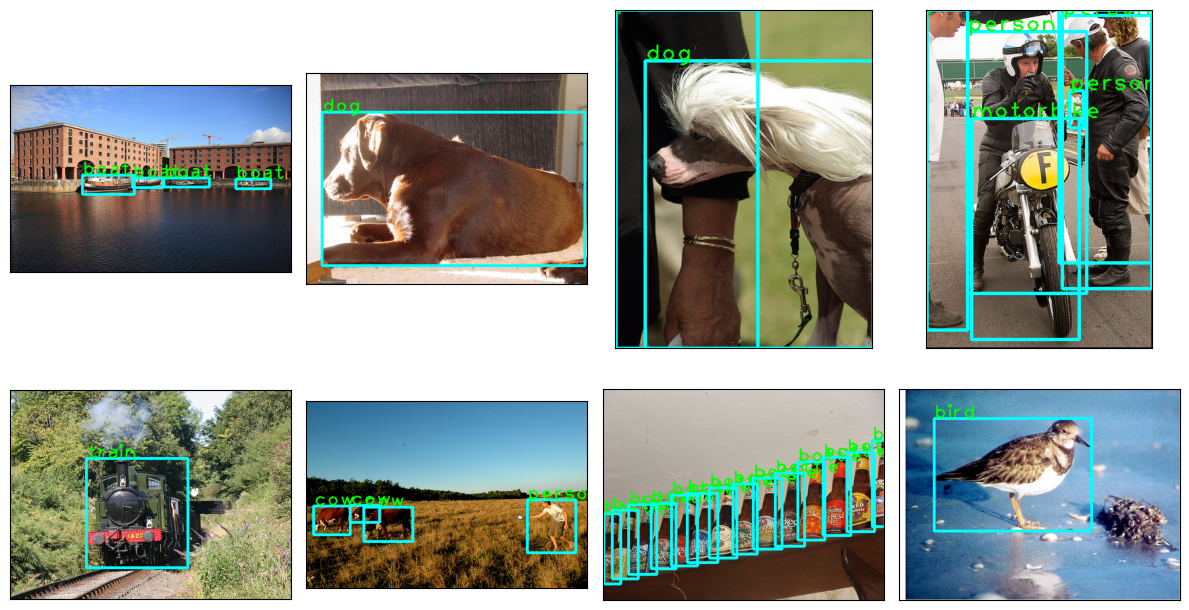

In [23]:
def visualize_images(trainloader, number_of_images=12):
    fig = plt.figure(figsize=(12,10))

    images, labels = next(iter(train_loader))

    num_rows = 3
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        # Convert to OpenCV image
        img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        
        #img = (img - img.min())/ (img.max() - img.min())

        
        
        #'size': {'width': '500', 'height': '442', 'depth': '3'}

        orig_w = int(label['annotation']['size']['width'])
        orig_h = int(label['annotation']['size']['height'])
        new_w = 448
        new_h = 448

        scale_x = 1.0
        scale_y = 1.0

        for obj_element in label['annotation']['object']:
            x_min = int(int(obj_element['bndbox']['xmin']) * scale_x)
            y_min = int(int(obj_element['bndbox']['ymin']) * scale_y)
            x_max = int(int(obj_element['bndbox']['xmax']) * scale_x)
            y_max = int(int(obj_element['bndbox']['ymax']) * scale_y)
            
            cv2.rectangle(img, (x_min, y_min), (x_max, y_max) , (255, 255, 0), thickness=3, lineType=cv2.LINE_8)
            cv2.putText(img, obj_element['name'], (x_min,y_min),fontFace=cv2.FONT_HERSHEY_PLAIN, fontScale=2.3, color=(0,255,0), thickness=2)        
       
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cmap='gray')

        #ax.set_title(f"{label.item()}: {train_data.classes[label.item()]}")

    fig.tight_layout()
    #plt.savefig('voc_dataset.pdf', dpi=300, bbox_inches="tight")
    plt.show()
visualize_images(train_loader)


#### Nvidia Locate Anything

In [24]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModel.from_pretrained(
    "nvidia/LocateAnything-3B",
    trust_remote_code=True,
    device_map="auto",
    torch_dtype="auto"
)

processor = AutoProcessor.from_pretrained(
    "nvidia/LocateAnything-3B",
    trust_remote_code=True
)

config.json: 0.00B [00:00, ?B/s]

U:\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\elp25hm\.cache\huggingface\hub\models--nvidia--LocateAnything-3B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


configuration_locateanything.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/LocateAnything-3B:
- configuration_locateanything.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_locateanything.py: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

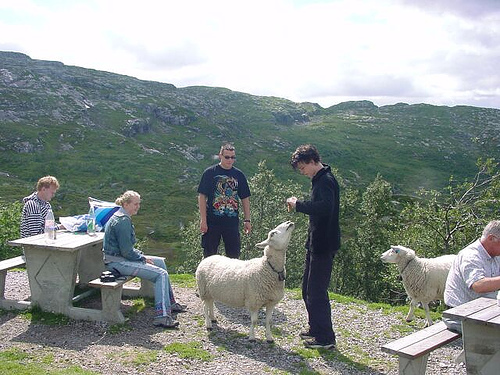

In [115]:
images[3]

In [132]:
image = images[3]
messages = [{
    "role": "user",
    "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": "Locate all instances of bottle, person and sheep in the image."}
    ]
}]


text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

images_list, videos_list = processor.process_vision_info(messages)

inputs = processor(
    text=[text],
    images=images_list,
    videos=videos_list,
    return_tensors="pt"
).to(model.device)

pixel_values = inputs["pixel_values"].to(model.dtype)

output = model.generate(
    pixel_values=pixel_values,
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    image_grid_hws=inputs["image_grid_hws"],
    tokenizer=processor.tokenizer,
    max_new_tokens=256,
    use_cache=True
)

print(output)

print(processor.tokenizer.decode(output[0], skip_special_tokens=True))

C:\Users\elp25hm\.cache\huggingface\modules\transformers_modules\nvidia\LocateAnything_hyphen_3B\c32291ca5e996f5a7a485845b4f57a233936bba0\generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))


<ref>bottle</ref><box><90><571><112><643></box><box><170><571><188><627></box><box><188><571><200><627></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><803></box><box><992><576><998><80

TypeError: argument 'ids': Can't extract `str` to `Vec`

In [68]:
print(inputs["pixel_values"].shape)
print(inputs["image_grid_hws"])

torch.Size([864, 3, 14, 14])
[[24 36]]


In [135]:

import re

text = output

boxes = re.findall(
    r"<box><(\d+)><(\d+)><(\d+)><(\d+)></box>",
    text
)

boxes = [tuple(map(int, b)) for b in boxes]

print(boxes)
print(output)

[(90, 571, 112, 643), (170, 571, 188, 627), (188, 571, 200, 627), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803), (992, 576, 998, 803)]
<ref>bottle</ref><box><90><571><112><643></box><box><170><571><188><627></bo

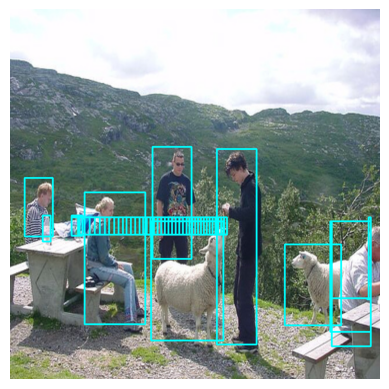

In [138]:
output
# Convert to OpenCV image
img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

#img = cv2.resize(img, (1024,1024)) 

#cv2.rectangle(img, (406, 435), (594, 580), (255, 255, 0), thickness=3, lineType=cv2.LINE_8)
        
#for box in boxes:
    #print(box)
#    cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]) , (255, 255, 0), thickness=3, lineType=cv2.LINE_8)
    #cv2.putText(img, obj_element['name'], (x_min,y_min),fontFace=cv2.FONT_HERSHEY_PLAIN, fontScale=2.3, color=(0,255,0), thickness=2)        
       
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cmap='gray')
plt.axis('off')
plt.savefig("output.png", bbox_inches="tight", dpi=300)